# How to Achieve Success by Streaming on Twitch​

By: Annette Martin​, Semen Petrov​, Kunanon Chaojaroenrat​, Ismail Cem Bayramoglu​

## Define success​:

* Follower growth since first observation is our main definition of success.

  * Absolute growth:
    * ΔFollowers(since) = Followers(t) − Followers(t0)
  * Relative growth:
    * GrowthRate(since) = (ΔFollowers(t) - Followers(t0)) / max(Followers(t0),1)

  * We use follower growth because it is measurable for any channel using public follower totals with repeated snapshots. We use *since first observation* due to the project deadline while preserving the same logic as longer-term growth.

* Secondary Success Indicators (Support Metrics):

    * These metrics support interpretation and recommendations (they are not the main success label unless explicitly modeled):

      * Audience size proxy: live_viewers_snapshot at collection time live_viewers_snaphot(note: this is a single-time snapshot, not an average).

      * Content performance proxy: vod_views_per_min computed from recent VODs.

      * Consistency and activity: videos_last_30d, days_active_30d, avg_stream_duration_min, std_stream_duration_min.

* We use UTC timestamps for collection time (snapshot_ts) and Berlin local date for grouping (snapshot_date) to keep daily aggregation consistent.”

 ## Stakeholders and Decisions

* Streamer: chooses content/category and streaming schedule to maximize follower growth. Follower growth since first observation (ΔFollowers_since, GrowthRate_since).

* Administrator: analyzes past performance and game trends, then recommends which games/categories and schedule changes are most likely to increase viewers and growth. follower growth (primary), plus support indicators (live_viewers_snapshot, vod_views_per_min, activity/consistency proxies).

* Moderator: manages chat and engagement (welcome raiders/new viewers, enforce rules, handle bans/timeouts) to improve retention and community quality. We cannot directly quantify moderation actions with our current dataset (no chat/retention logs). Moderation is discussed as a qualitative factor that may influence retention and growth, but it is not modeled as a measurable driver.

* Sponsor: selects streamers to support based on measurable growth and engagement proxies (vod_views_per_min, live_viewers_snapshot, consistency/activity proxies).

# Kaggle data

In [ ]:
# Imports (Kaggle + Twitch)
import os
import time
import re

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
from tqdm import tqdm

import kagglehub

from datetime import datetime, timezone, timedelta


In [ ]:
# Define datasets (Kaggle)
datasets = {
    "streamers": "aayushmishra1512/twitchdata",
    "top_games": "rankirsh/evolution-of-top-games-on-twitch"
}

dfs = {}
encodings_to_try = ["utf-8", "latin-1", "cp1252", "iso-8859-1"]

for dataset_name, kaggle_path in datasets.items():
    folder_path = kagglehub.dataset_download(kaggle_path)
    print(f"\nDownloaded: {dataset_name} -> {folder_path}")

    for fname in os.listdir(folder_path):
        full_path = os.path.join(folder_path, fname)
        if not os.path.isfile(full_path):
            continue

        base, ext = os.path.splitext(fname)
        ext = ext.lower()

        try:
            if ext == ".csv":
                df = None
                for enc in encodings_to_try:
                    try:
                        df = pd.read_csv(full_path, encoding=enc)
                        break
                    except UnicodeDecodeError:
                        continue
                if df is None:
                    print(f"⚠️ Could not decode CSV: {fname}")
                    continue

            elif ext in [".xlsx", ".xls"]:
                df = pd.read_excel(full_path)

            else:
                continue  # skip non-tabular files

            key = f"{dataset_name}_{base}"
            if key in dfs:
                key = f"{key}_{len(dfs)}"

            dfs[key] = df
            print(f"✓ Loaded {key}: {df.shape[0]} rows × {df.shape[1]} cols")

        except Exception as e:
            print(f"✗ Error loading {fname}: {e}")

print(f"\nTotal tables loaded: {len(dfs)}")


Using Colab cache for faster access to the 'twitchdata' dataset.

Downloaded: streamers -> /kaggle/input/twitchdata
✓ Loaded streamers_twitchdata-update: 1000 rows × 11 cols
Using Colab cache for faster access to the 'evolution-of-top-games-on-twitch' dataset.

Downloaded: top_games -> /kaggle/input/evolution-of-top-games-on-twitch
✓ Loaded top_games_Twitch_global_data: 105 rows × 9 cols
✓ Loaded top_games_Twitch_game_data: 21000 rows × 12 cols

Total tables loaded: 3


In [ ]:
for k in dfs.keys():
    print(k)

streamers_twitchdata-update
top_games_Twitch_global_data
top_games_Twitch_game_data


In [ ]:
display(dfs["streamers_twitchdata-update"].head())
display(dfs["top_games_Twitch_global_data"].head())
display(dfs["top_games_Twitch_game_data"].head())

,Channel,Watch time(Minutes),Stream time(minutes),Peak viewers,Average viewers,Followers,Followers gained,Views gained,Partnered,Mature,Language
0,xQcOW,6196161750,215250,222720,27716,3246298,1734810,93036735,True,False,English
1,summit1g,6091677300,211845,310998,25610,5310163,1370184,89705964,True,False,English
2,Gaules,5644590915,515280,387315,10976,1767635,1023779,102611607,True,True,Portuguese
3,ESL_CSGO,3970318140,517740,300575,7714,3944850,703986,106546942,True,False,English
4,Tfue,3671000070,123660,285644,29602,8938903,2068424,78998587,True,False,English


,year,Month,Hours_watched,Avg_viewers,Peak_viewers,Streams,Avg_channels,Games_streamed,Viewer_ratio
0,2016,1,480241904,646355,1275257,7701675,20076,12149,29.08
1,2016,2,441859897,635769,1308032,7038520,20427,12134,28.98
2,2016,3,490669308,660389,1591551,7390957,20271,12234,28.92
3,2016,4,377975447,525696,1775120,6869719,16791,12282,28.80
4,2016,5,449836631,605432,1438962,7535519,19394,12424,28.85


,Rank,Game,Month,Year,Hours_watched,Hours_streamed,Peak_viewers,Peak_channels,Streamers,Avg_viewers,Avg_channels,Avg_viewer_ratio
0,1,League of Legends,1,2016,94377226,1362044,530270,2903,129172,127021,1833,69.29
1,2,Counter-Strike: Global Offensive,1,2016,47832863,830105,372654,2197,120849,64378,1117,57.62
2,3,Dota 2,1,2016,45185893,433397,315083,1100,44074,60815,583,104.26
3,4,Hearthstone,1,2016,39936159,235903,131357,517,36170,53749,317,169.29
4,5,Call of Duty: Black Ops III,1,2016,16153057,1151578,71639,3620,214054,21740,1549,14.03


# Analysis

In [ ]:
top10 = dfs["top_games_Twitch_game_data"].query("Rank <= 10")

game_counts_df = (
    top10.groupby("Game", as_index=False)
        .size()
        .rename(columns={"size": "top10_months"})
        .query("top10_months >= 10")
        .sort_values("top10_months", ascending=False)
)

print(f"Games appearing in monthly Top 10 for >=10 months: {len(game_counts_df)}")
display(game_counts_df.head(20))


Games appearing in monthly Top 10 for >=10 months: 16


,Game,top10_months
51,League of Legends,105
23,Dota 2,90
16,Counter-Strike: Global Offensive,87
43,Fortnite,81
45,Grand Theft Auto V,79
50,Just Chatting,72
85,World of Warcraft,62
53,Minecraft,58
83,VALORANT,50
46,Hearthstone,45


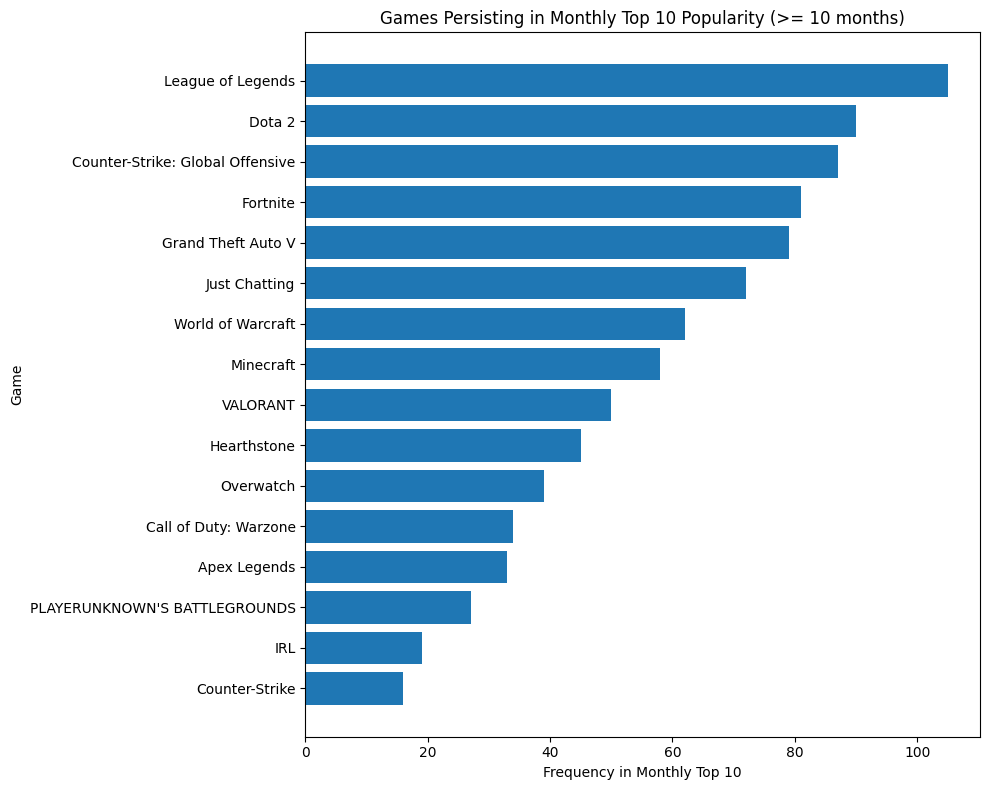

In [ ]:
# Plot: how often games appear in monthly Top 10 (persistent games)
plot_df = game_counts_df.sort_values("top10_months", ascending=False)

plt.figure(figsize=(10, 8))  # better for ~16 games
plt.barh(plot_df["Game"], plot_df["top10_months"])
plt.gca().invert_yaxis()

plt.ylabel("Game")
plt.xlabel("Frequency in Monthly Top 10")
plt.title("Games Persisting in Monthly Top 10 Popularity (>= 10 months)")
plt.tight_layout()
plt.show()



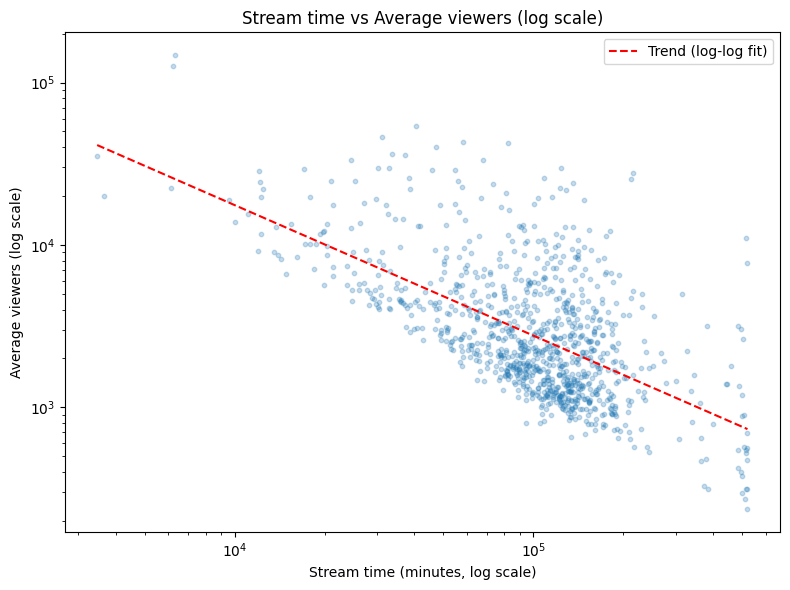

In [ ]:
df = dfs["streamers_twitchdata-update"].copy()

# Convert to numeric and drop missing/invalid rows
x = pd.to_numeric(df["Stream time(minutes)"], errors="coerce")
y = pd.to_numeric(df["Average viewers"], errors="coerce")
df_xy = pd.DataFrame({"stream_time_min": x, "avg_viewers": y}).dropna()
df_xy = df_xy[(df_xy["stream_time_min"] > 0) & (df_xy["avg_viewers"] > 0)]

# Fit a trend line in log-log space (handles skew better)
lx = np.log10(df_xy["stream_time_min"])
ly = np.log10(df_xy["avg_viewers"])
m, b = np.polyfit(lx, ly, 1)

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(df_xy["stream_time_min"], df_xy["avg_viewers"], alpha=0.25, s=10)

# Trend line (convert back to original scale)
x_line = np.linspace(df_xy["stream_time_min"].min(), df_xy["stream_time_min"].max(), 200)
y_line = 10 ** (m * np.log10(x_line) + b)
plt.plot(x_line, y_line, "r--", label="Trend (log-log fit)")

# Use log scales so outliers don’t ruin the chart
plt.xscale("log")
plt.yscale("log")

plt.title("Stream time vs Average viewers (log scale)")
plt.xlabel("Stream time (minutes, log scale)")
plt.ylabel("Average viewers (log scale)")
plt.legend()
plt.tight_layout()
plt.show()


Using log scales (to handle extreme outliers), we observe a negative association between total stream time and average viewers in the Kaggle dataset, suggesting that longer streaming is not automatically linked to higher viewership and may reflect underlying differences in channel size

# Moving Kaggle Data to BigQuery

In [ ]:
# This has already been uploaded, no need to do it again
'''
from google.colab import auth
from google.cloud import bigquery

print("UPLOAD DATAFRAMES TO BIGQUERY")

# Check what dataframes are available
print(f"\nFound {len(dfs)} dataframe(s) to upload:")
for name, df in dfs.items():
    print(f"  - {name}: {df.shape[0]} rows × {df.shape[1]} columns")

# AUTHENTICATE AND SETUP
print("BigQuery Setup")

# Authenticate
auth.authenticate_user()
print("✓ Authenticated with Google Cloud")

# Get BigQuery details
project_id = input("\nEnter your Google Cloud Project ID: ").strip()
dataset_name = input("Enter BigQuery dataset name (e.g., 'twitch_data'): ").strip().lower().replace(' ', '_').replace('-', '_')

# UPLOAD TO BIGQUERY
try:
    # Initialize BigQuery client
    client = bigquery.Client(project=project_id)

    # Create dataset if it doesn't exist
    dataset_id = f"{project_id}.{dataset_name}"
    dataset = bigquery.Dataset(dataset_id)
    dataset.location = "US"

    try:
        dataset = client.create_dataset(dataset, exists_ok=True)
        print(f"\n✓ Dataset '{dataset_name}' ready in project '{project_id}'")
    except Exception as e:
        print(f"\n⚠ Dataset creation note: {e}")
        print("Continuing with upload...")

    print("Uploading tables to BigQuery...")

    successful_uploads = 0
    failed_uploads = []

    for table_name, df in dfs.items():
        try:
            # Clean table name (BigQuery requirements)
            clean_table_name = table_name.lower().replace(' ', '_').replace('-', '_')
            table_id = f"{dataset_id}.{clean_table_name}"

            # Clean column names (BigQuery requirements)
            # Remove special characters and replace with underscores
            df_clean = df.copy()
            df_clean.columns = [
                col.replace('(', '_')
                   .replace(')', '_')
                   .replace(' ', '_')
                   .replace('-', '_')
                   .replace('.', '_')
                   .replace('/', '_')
                   .replace('\\', '_')
                   .replace(',', '_')
                   .replace(';', '_')
                   .replace(':', '_')
                   .replace('!', '_')
                   .replace('?', '_')
                   .replace('#', '_')
                   .replace('&', '_')
                   .replace('%', '_')
                   .replace('*', '_')
                   .replace('+', '_')
                   .replace('=', '_')
                   .replace('<', '_')
                   .replace('>', '_')
                   .replace('[', '_')
                   .replace(']', '_')
                   .replace('{', '_')
                   .replace('}', '_')
                   .replace('|', '_')
                   .replace('~', '_')
                   .replace('`', '_')
                   .replace('"', '_')
                   .replace("'", '_')
                   .strip('_')  # Remove leading/trailing underscores
                for col in df.columns
            ]

            # Remove consecutive underscores
            df_clean.columns = [
                '_'.join(filter(None, col.split('_')))
                for col in df_clean.columns
            ]

            # Configure the upload
            job_config = bigquery.LoadJobConfig(
                write_disposition="WRITE_TRUNCATE",  # Overwrite if exists
                autodetect=True  # Auto-detect schema
            )

            # Upload the dataframe
            print(f"Uploading {clean_table_name}...", end=" ")
            job = client.load_table_from_dataframe(
                df_clean, table_id, job_config=job_config
            )
            job.result()  # Wait for completion

            print(f"✓ ({df.shape[0]} rows)")
            successful_uploads += 1

        except Exception as e:
            print(f"✗")
            print(f"  Error: {e}")
            failed_uploads.append(table_name)

    print(f"\n✓ Successfully uploaded {successful_uploads}/{len(dfs)} table(s)")

    if failed_uploads:
        print(f"\n⚠ Failed uploads: {', '.join(failed_uploads)}")

    print(f"\nYour data is now in BigQuery:")
    print(f"  Project: {project_id}")
    print(f"  Dataset: {dataset_name}")
    print(f"  Tables: {', '.join([name for name in dfs.keys()])}")
    print(f"\nView your data at:")
    print(f"  https://console.cloud.google.com/bigquery?project={project_id}")
    print(f"\nExample queries:")
    for name in dfs.keys():
        clean_name = name.lower().replace(' ', '_').replace('-', '_')
        print(f"  SELECT * FROM `{project_id}.{dataset_name}.{clean_name}` LIMIT 10;")
    print("=" * 80)

except Exception as e:
    print(f"\n✗ Error uploading to BigQuery: {e}")
    print("\nTroubleshooting:")
    print("  1. Verify your project exists at: https://console.cloud.google.com/")
    print("  2. Enable BigQuery API: https://console.cloud.google.com/apis/library/bigquery.googleapis.com")
    print("  3. Check your Project ID is correct (use hyphens, not underscores)")
    print(f"  4. Current Project ID attempt: '{project_id}'")
    '''

'\nfrom google.colab import auth\nfrom google.cloud import bigquery\n\nprint("UPLOAD DATAFRAMES TO BIGQUERY")\n\n# Check what dataframes are available\nprint(f"\nFound {len(dfs)} dataframe(s) to upload:")\nfor name, df in dfs.items():\n    print(f"  - {name}: {df.shape[0]} rows × {df.shape[1]} columns")\n\n# AUTHENTICATE AND SETUP\nprint("BigQuery Setup")\n\n# Authenticate\nauth.authenticate_user()\nprint("✓ Authenticated with Google Cloud")\n\n# Get BigQuery details\nproject_id = input("\nEnter your Google Cloud Project ID: ").strip()\ndataset_name = input("Enter BigQuery dataset name (e.g., \'twitch_data\'): ").strip().lower().replace(\' \', \'_\').replace(\'-\', \'_\')\n\n# UPLOAD TO BIGQUERY\ntry:\n    # Initialize BigQuery client\n    client = bigquery.Client(project=project_id)\n\n    # Create dataset if it doesn\'t exist\n    dataset_id = f"{project_id}.{dataset_name}"\n    dataset = bigquery.Dataset(dataset_id)\n    dataset.location = "US"\n\n    try:\n        dataset = client.

# Twitch direct information

In [ ]:
# ===== Block 1: Twitch auth + shared paths + robust Helix GET =====
from google.colab import userdata, drive
import os, time, requests, pandas as pd
from datetime import datetime, timezone, timedelta
import numpy as np
from tqdm import tqdm
import re

drive.mount("/content/drive")

BASE_DIR = "/content/drive/MyDrive/Twitch_project/data"
os.makedirs(BASE_DIR, exist_ok=True)

COHORT_FILE = os.path.join(BASE_DIR, "cohort.csv")
SNAP_FILE   = os.path.join(BASE_DIR, "twitch_daily_snapshots.csv")

print("BASE_DIR:", BASE_DIR)
print("COHORT_FILE exists:", os.path.exists(COHORT_FILE))
print("SNAP_FILE exists:", os.path.exists(SNAP_FILE))

TWITCH_CLIENT_ID = userdata.get("TWITCH_CLIENT_ID")
TWITCH_CLIENT_SECRET = userdata.get("TWITCH_CLIENT_SECRET")
if not TWITCH_CLIENT_ID or not TWITCH_CLIENT_SECRET:
    raise ValueError("Missing Twitch secrets (TWITCH_CLIENT_ID / TWITCH_CLIENT_SECRET) in Colab Secrets.")

def get_app_token():
    resp = requests.post(
        "https://id.twitch.tv/oauth2/token",
        data={
            "client_id": TWITCH_CLIENT_ID,
            "client_secret": TWITCH_CLIENT_SECRET,
            "grant_type": "client_credentials",
        },
        timeout=20,
    )
    resp.raise_for_status()
    j = resp.json()
    return j["access_token"], time.time() + j["expires_in"] - 60

TOKEN, TOKEN_EXPIRY = get_app_token()

def ensure_token():
    global TOKEN, TOKEN_EXPIRY
    if time.time() >= TOKEN_EXPIRY:
        TOKEN, TOKEN_EXPIRY = get_app_token()

def helix_get(endpoint, params=None, max_retries=6, timeout=20):
    """
    Robust GET for Twitch Helix.
    Retries on 429 / 5xx, refreshes token on 401/403.
    """
    url = f"https://api.twitch.tv/helix/{endpoint.lstrip('/')}"
    params = params or {}

    for attempt in range(max_retries):
        ensure_token()
        headers = {"Client-ID": TWITCH_CLIENT_ID, "Authorization": f"Bearer {TOKEN}"}

        resp = requests.get(url, headers=headers, params=params, timeout=timeout)

        if resp.status_code == 429:
            time.sleep(min(2 ** attempt, 60))
            continue

        if resp.status_code in (401, 403):
            globals()["TOKEN"], globals()["TOKEN_EXPIRY"] = get_app_token()
            time.sleep(1)
            continue

        if resp.status_code >= 500:
            time.sleep(min(2 ** attempt, 60))
            continue

        resp.raise_for_status()
        return resp.json()

    raise RuntimeError(f"Helix GET failed after retries: {endpoint} params={params}")


Mounted at /content/drive
BASE_DIR: /content/drive/MyDrive/Twitch_project/data
COHORT_FILE exists: True
SNAP_FILE exists: True


In [ ]:
# No need to run this
'''
# ===== Block 2: Cohort check + optional repair (OFF by default) =====
import pandas as pd
from tqdm import tqdm
import time, requests

TARGET_SIZE = 500

# 🔒 SAFETY SWITCHES (DEFAULT = SAFE)
ALLOW_COHORT_REPAIR = False   # must be manually set True to ever change cohort.csv
ALLOW_LIVE_SAMPLING = False   # must be True as well to sample new candidates

def helix_get_full_url(url, params=None, max_retries=6, timeout=20):
    """Full-URL Helix GET. Named differently so it cannot overwrite Block 1's helix_get()."""
    for attempt in range(max_retries):
        ensure_token()
        headers = {"Client-ID": TWITCH_CLIENT_ID, "Authorization": f"Bearer {TOKEN}"}
        r = requests.get(url, headers=headers, params=params, timeout=timeout)

        if r.status_code == 429:
            time.sleep(min(2 ** attempt, 60))
            continue
        if r.status_code in (401, 403):
            globals()["TOKEN"], globals()["TOKEN_EXPIRY"] = get_app_token()
            time.sleep(1)
            continue
        if r.status_code >= 500:
            time.sleep(min(2 ** attempt, 60))
            continue

        r.raise_for_status()
        return r.json()

    raise RuntimeError(f"Helix GET failed after retries: {url}")

def validate_logins(usernames, chunk=100):
    """Return list of usernames that Twitch /users confirms exist."""
    valid = []
    for i in tqdm(range(0, len(usernames), chunk), desc="Validating cohort"):
        batch = usernames[i:i+chunk]
        params = [("login", u) for u in batch]  # repeated 'login' params is correct
        js = helix_get_full_url("https://api.twitch.tv/helix/users", params=params)
        found = {u["login"].lower() for u in js.get("data", [])}
        valid.extend([u for u in batch if u.lower() in found])
    return valid

# ---- 1) Load cohort ----
cohort = pd.read_csv(COHORT_FILE)["username"].dropna().astype(str).tolist()
cohort = [u.strip() for u in cohort if u.strip()]
cohort = list(dict.fromkeys(cohort))  # de-dupe preserve order
print("Loaded cohort usernames:", len(cohort))

# ---- 2) Enforce exact size ----
if len(cohort) != TARGET_SIZE:
    raise ValueError(
        f"cohort.csv must contain exactly {TARGET_SIZE} usernames.\n"
        f"Found: {len(cohort)}.\n"
        f"Fix: replace cohort.csv with the correct shared one (do NOT regenerate)."
    )

# ---- 3) Validate logins via Helix ----
valid = validate_logins(cohort)
valid_lower = {v.lower() for v in valid}
invalid = [u for u in cohort if u.lower() not in valid_lower]

print("\n✅ Cohort validation result")
print("Valid usernames:", len(valid))
print("Invalid usernames:", len(invalid))
if invalid:
    print("Example invalid (first 10):", invalid[:10])

# ---- 4) Default behavior: STOP if invalid ----
if invalid and (not ALLOW_COHORT_REPAIR):
    raise ValueError(
        f"\n❌ Cohort contains {len(invalid)} invalid usernames.\n"
        f"DO NOT collect snapshots with a broken cohort.\n"
        f"Fix options:\n"
        f"  (A) Replace cohort.csv with a clean one\n"
        f"  (B) If you REALLY want auto-repair: set ALLOW_COHORT_REPAIR=True AND ALLOW_LIVE_SAMPLING=True\n"
    )

# ---- 5) Repair mode (ONLY if BOTH switches are True) ----
if invalid and ALLOW_COHORT_REPAIR:
    if not ALLOW_LIVE_SAMPLING:
        raise ValueError(
            "Repair requested but ALLOW_LIVE_SAMPLING=False.\n"
            "Set ALLOW_LIVE_SAMPLING=True too, otherwise repair is disabled."
        )

    if "get_live_streamers_sample" not in globals():
        raise NameError(
            "get_live_streamers_sample() not found.\n"
            "Repair mode needs live sampling; restore those functions."
        )

    need = TARGET_SIZE - len(valid)
    print(f"\n⚠ Repair mode ON. Need to replace {len(invalid)} invalid entries. Top-up needed: {need}")

    candidates = list(get_live_streamers_sample(max_streamers=4000))
    existing_lower = {u.lower() for u in valid}
    candidates = [u for u in candidates if u.lower() not in existing_lower]

    topup_valid = validate_logins(candidates)
    topup_valid = [u for u in topup_valid if u.lower() not in existing_lower]

    repaired = valid + topup_valid[:need]
    repaired = repaired[:TARGET_SIZE]

    if len(repaired) != TARGET_SIZE:
        raise RuntimeError(f"Repair failed. Final cohort size: {len(repaired)} (expected {TARGET_SIZE})")

    pd.DataFrame({"username": repaired}).to_csv(COHORT_FILE, index=False)
    print("✅ Repaired cohort saved:", COHORT_FILE)

# ---- 6) Set sample_usernames for downstream blocks ----
sample_usernames = pd.read_csv(COHORT_FILE)["username"].dropna().astype(str).tolist()
print("\n✅ Cohort ready:", len(sample_usernames))


Loaded cohort usernames: 500


Validating cohort: 100%|██████████| 5/5 [00:00<00:00,  7.81it/s]


✅ Cohort validation result
Valid usernames: 498
Invalid usernames: 2
Example invalid (first 10): ['c1aym0re30', 'casalslotsbr']


ValueError: 
❌ Cohort contains 2 invalid usernames.
DO NOT collect snapshots with a broken cohort.
Fix options:
  (A) Replace cohort.csv with a clean one
  (B) If you REALLY want auto-repair: set ALLOW_COHORT_REPAIR=True AND ALLOW_LIVE_SAMPLING=True


In [ ]:
# ===== Block 3: Build today's snapshot from the cohort =====
from datetime import datetime, timezone, timedelta
from zoneinfo import ZoneInfo
import numpy as np
import pandas as pd
from tqdm import tqdm
import re, time, requests

BERLIN_TZ = ZoneInfo("Europe/Berlin")

def parse_twitch_duration_to_minutes(s: str) -> float:
    if not isinstance(s, str) or not s.strip():
        return 0.0
    h = re.search(r"(\d+)h", s)
    m = re.search(r"(\d+)m", s)
    sec = re.search(r"(\d+)s", s)
    minutes = 0.0
    if h: minutes += int(h.group(1)) * 60
    if m: minutes += int(m.group(1))
    if sec: minutes += int(sec.group(1)) / 60
    return minutes

def helix_get_full_url(url, params=None, max_retries=6, timeout=20):
    """Full-URL Helix GET. Named differently so it cannot overwrite Block 1's helix_get()."""
    for attempt in range(max_retries):
        ensure_token()
        headers = {"Client-ID": TWITCH_CLIENT_ID, "Authorization": f"Bearer {TOKEN}"}
        r = requests.get(url, headers=headers, params=params, timeout=timeout)

        if r.status_code == 429:
            time.sleep(min(2 ** attempt, 60))
            continue
        if r.status_code in (401, 403):
            globals()["TOKEN"], globals()["TOKEN_EXPIRY"] = get_app_token()
            time.sleep(1)
            continue
        if r.status_code >= 500:
            time.sleep(min(2 ** attempt, 60))
            continue

        r.raise_for_status()
        return r.json()

    raise RuntimeError(f"Helix GET failed after retries: {url}")

def build_quality_features(username: str, now_utc: datetime, snapshot_date_berlin: str):
    # 1) user info
    user_js = helix_get_full_url("https://api.twitch.tv/helix/users", params={"login": username})
    data = user_js.get("data", [])
    if not data:
        return None
    user = data[0]
    user_id = str(user["id"]).strip()

    # 2) followers total
    fol_js = helix_get_full_url(
        "https://api.twitch.tv/helix/channels/followers",
        params={"broadcaster_id": user_id}
    )
    followers_total = int(fol_js.get("total", 0))

    # 3) videos (VODs)
    vids_js = helix_get_full_url(
        "https://api.twitch.tv/helix/videos",
        params={"user_id": user_id, "first": 100}
    )
    videos = vids_js.get("data", [])

    avg_vod_views = (sum(v.get("view_count", 0) for v in videos) / len(videos)) if videos else 0.0
    durations = [parse_twitch_duration_to_minutes(v.get("duration", "")) for v in videos]
    avg_duration = (sum(durations) / len(durations)) if durations else 0.0
    std_duration = float(np.std(durations)) if len(durations) > 1 else 0.0

    # Activity last 30d (UTC-consistent)
    cutoff_30d = now_utc - timedelta(days=30)
    created_times = []
    for v in videos:
        ts = v.get("created_at")
        if ts:
            try:
                created_times.append(datetime.fromisoformat(ts.replace("Z", "+00:00")))
            except:
                pass
    videos_last_30d = sum(1 for dt in created_times if dt >= cutoff_30d)
    days_active_30d = len({dt.date() for dt in created_times if dt >= cutoff_30d})

    # 4) live viewers snapshot
    streams_js = helix_get_full_url("https://api.twitch.tv/helix/streams", params={"user_id": user_id})
    sdata = streams_js.get("data", [])
    live_viewers_snapshot = int(sdata[0].get("viewer_count", 0)) if sdata else 0

    # Account age
    created_at = datetime.fromisoformat(user["created_at"].replace("Z", "+00:00"))
    account_age_days = (now_utc - created_at).days

    return {
        "snapshot_ts": now_utc.isoformat(),        # exact moment (UTC)
        "snapshot_date": snapshot_date_berlin,     # Berlin date label
        "username": str(username).strip(),
        "user_id": user_id,
        "language": user.get("broadcaster_language"),
        "broadcaster_type": user.get("broadcaster_type"),
        "followers_total": followers_total,
        "live_viewers_snapshot": live_viewers_snapshot,
        "avg_vod_views": float(avg_vod_views),
        "videos_last_30d": int(videos_last_30d),
        "days_active_30d": int(days_active_30d),
        "avg_stream_duration_min": float(avg_duration),
        "std_stream_duration_min": float(std_duration),
        "followers_per_video_30d": (followers_total / videos_last_30d) if videos_last_30d > 0 else 0.0,
        "vod_views_per_min": (avg_vod_views / avg_duration) if avg_duration > 0 else 0.0,
        "account_age_days": int(account_age_days),
        "description_length": len(user.get("description") or ""),
    }

# --- Load cohort ---
sample_usernames = pd.read_csv(COHORT_FILE)["username"].dropna().astype(str).tolist()
sample_usernames = [u.strip() for u in sample_usernames if u.strip()]
print("Cohort size:", len(sample_usernames))

# --- One timestamp for the whole run ---
now_utc = datetime.now(timezone.utc)
snapshot_date_berlin = now_utc.astimezone(BERLIN_TZ).date().isoformat()
print("Snapshot date (Berlin):", snapshot_date_berlin)
print("Snapshot ts (UTC):", now_utc.isoformat())

# --- Build snapshot ---
rows, failed_users = [], []
for u in tqdm(sample_usernames, desc="Building snapshot"):
    row = build_quality_features(u, now_utc, snapshot_date_berlin)
    if row:
        rows.append(row)
    else:
        failed_users.append(u)

df_streamers = pd.DataFrame(rows)
print("Built rows:", len(df_streamers))
print("Failed:", len(failed_users))
if failed_users[:10]:
    print("Example failed:", failed_users[:10])

if df_streamers.empty:
    raise ValueError("df_streamers is empty. Twitch API calls failed or cohort is invalid.")

display(df_streamers.head())


Cohort size: 500
Snapshot date (Berlin): 2026-01-15
Snapshot ts (UTC): 2026-01-15T01:36:21.733787+00:00


Building snapshot: 100%|██████████| 500/500 [02:38<00:00,  3.16it/s]

Built rows: 496
Failed: 4
Example failed: ['bambihaze', 'c1aym0re30', 'clout', 'ded_ivan_ded']


,snapshot_ts,snapshot_date,username,user_id,language,broadcaster_type,followers_total,live_viewers_snapshot,avg_vod_views,videos_last_30d,days_active_30d,avg_stream_duration_min,std_stream_duration_min,followers_per_video_30d,vod_views_per_min,account_age_days,description_length
0,2026-01-15T01:36:21.733787+00:00,2026-01-15,1indio,196138758,None,partner,10016,0,3434.290000,51,29,222.351167,173.277853,196.392157,15.445343,2892,285
1,2026-01-15T01:36:21.733787+00:00,2026-01-15,247jynxzi,1171769612,None,partner,287809,42,0.000000,0,0,0.000000,0.000000,0.000000,0.000000,444,45
2,2026-01-15T01:36:21.733787+00:00,2026-01-15,2964872,49992452,None,partner,7787,0,1612.069444,39,29,305.154398,155.098880,199.666667,5.282799,4479,113
3,2026-01-15T01:36:21.733787+00:00,2026-01-15,2cheesenips,775234979,None,affiliate,495,0,163.363636,10,9,161.563636,88.773207,49.500000,1.011141,1421,182
4,2026-01-15T01:36:21.733787+00:00,2026-01-15,3moth,141129992,None,partner,10670,0,903.036145,25,24,248.731727,132.651285,426.800000,3.630563,3327,20


In [ ]:
import os
import pandas as pd

today = df_streamers.copy()
if today.empty:
    raise ValueError("Today's snapshot is empty. Stop and fix API before saving.")

# Normalize keys
today["snapshot_date"] = pd.to_datetime(today["snapshot_date"], errors="coerce").dt.date.astype(str)
today["user_id"] = today["user_id"].astype(str).str.strip()
today["username"] = today["username"].astype(str).str.strip()

# Load existing
if os.path.exists(SNAP_FILE):
    old = pd.read_csv(SNAP_FILE)
    old["snapshot_date"] = pd.to_datetime(old["snapshot_date"], errors="coerce").dt.date.astype(str)
    old["user_id"] = old["user_id"].astype(str).str.strip()
    if "username" in old.columns:
        old["username"] = old["username"].astype(str).str.strip()
    df_all = pd.concat([old, today], ignore_index=True)
else:
    df_all = today.copy()

# If snapshot_ts exists, sort so "keep last" means latest run wins
if "snapshot_ts" in df_all.columns:
    df_all["snapshot_ts"] = pd.to_datetime(df_all["snapshot_ts"], errors="coerce", utc=True)
    df_all = df_all.sort_values("snapshot_ts")

# Dedupe: one row per streamer per day
df_all = df_all.drop_duplicates(subset=["snapshot_date", "user_id"], keep="last")

df_all.to_csv(SNAP_FILE, index=False)

print("Saved today's rows:", len(today))
print("Total stored rows:", len(df_all))
print(df_all["snapshot_date"].value_counts().head(10))
print("Duplicates left:", df_all.duplicated(subset=["snapshot_date","user_id"]).sum())


Saved today's rows: 496
Total stored rows: 1494
snapshot_date
2026-01-13    500
2026-01-14    498
2026-01-15    496
Name: count, dtype: int64
Duplicates left: 0


In [ ]:
import os, pandas as pd

print("SNAP_FILE:", SNAP_FILE)
print("Exists:", os.path.exists(SNAP_FILE))

snap = pd.read_csv(SNAP_FILE)
print("Rows:", len(snap))
print("Unique dates:", sorted(snap["snapshot_date"].unique())[:10])
print("Counts per date:")
print(snap["snapshot_date"].value_counts().sort_index())

print("\nCOHORT_FILE:", COHORT_FILE)
cohort = pd.read_csv(COHORT_FILE)
print("Cohort size:", len(cohort))
print("First 5 usernames:", cohort["username"].head().tolist())


SNAP_FILE: /content/drive/MyDrive/Twitch_project/data/twitch_daily_snapshots.csv
Exists: True
Rows: 998
Unique dates: ['2026-01-13', '2026-01-14']
Counts per date:
snapshot_date
2026-01-13    500
2026-01-14    498
Name: count, dtype: int64

COHORT_FILE: /content/drive/MyDrive/Twitch_project/data/cohort.csv
Cohort size: 500
First 5 usernames: ['1indio', '247jynxzi', '2964872', '2cheesenips', '3moth']


# Compute the success label since first observation
* Build growth features from twitch_daily_snapshots.csv


In [ ]:
# Compute the success label (follower growth, fallback to since-first)
snap = pd.read_csv("/content/drive/MyDrive/Twitch_project/data/twitch_daily_snapshots.csv")

# Ensure correct types + sort
snap["snapshot_date"] = pd.to_datetime(snap["snapshot_date"])
snap = snap.drop_duplicates(subset=["user_id", "snapshot_date"], keep="last")
snap = snap.sort_values(["user_id", "snapshot_date"])

DAYS = 7
snap["date_minus_7"] = snap["snapshot_date"] - pd.Timedelta(days=DAYS)

# Alternative approach: manual lookup for 7-day-ago followers
def get_7d_ago_followers(group):
    group = group.sort_values("snapshot_date").reset_index(drop=True)
    followers_7d_ago = []

    for idx, row in group.iterrows():
        target_date = row["date_minus_7"]
        # Find the closest snapshot on or before target_date
        mask = group["snapshot_date"] <= target_date
        if mask.any():
            closest_idx = group.loc[mask, "snapshot_date"].idxmax()
            followers_7d_ago.append(group.loc[closest_idx, "followers_total"])
        else:
            followers_7d_ago.append(None)

    group["followers_7d_ago"] = followers_7d_ago
    return group

# Apply the function to each user
growth = snap.groupby("user_id", group_keys=False).apply(get_7d_ago_followers)

# growth (main success definition)
growth["growth_7d_abs"] = growth["followers_total"] - growth["followers_7d_ago"]
growth["growth_7d_pct"] = growth["growth_7d_abs"] / growth["followers_7d_ago"].clip(lower=1)

# Fallback: since first snapshot
first_followers = growth.groupby("user_id")["followers_total"].transform("first")
growth["growth_since_first_abs"] = growth["followers_total"] - first_followers
growth["growth_since_first_pct"] = growth["growth_since_first_abs"] / first_followers.clip(lower=1)

print("Total snapshot rows:", len(snap))
print("Rows with 7d labels available:", growth["followers_7d_ago"].notna().sum())

display(
    growth[[
        "snapshot_date", "username", "user_id", "followers_total",
        "followers_7d_ago", "growth_7d_abs", "growth_7d_pct",
        "growth_since_first_abs", "growth_since_first_pct"
    ]]
    .sort_values(["snapshot_date", "growth_since_first_abs"], ascending=[False, False])
    .head(15)
)

Total snapshot rows: 978
Rows with 7d labels available: 0


/tmp/ipython-input-218971188.py:31: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  growth = snap.groupby("user_id", group_keys=False).apply(get_7d_ago_followers)


,snapshot_date,username,user_id,followers_total,followers_7d_ago,growth_7d_abs,growth_7d_pct,growth_since_first_abs,growth_since_first_pct
1,2026-01-13,cepreu_inq,51529432,142047,None,NaN,NaN,19597,0.160041
1,2026-01-13,caseoh_,267160288,8019397,None,NaN,NaN,13523,0.001689
1,2026-01-13,cloakzy,81687332,2962618,None,NaN,NaN,7917,0.002679
1,2026-01-13,baroknowsbetter,823433067,16498,None,NaN,NaN,7002,0.737363
1,2026-01-13,247jynxzi,1171769612,286534,None,NaN,NaN,4704,0.016691
1,2026-01-13,alexcrasherss,506751031,515066,None,NaN,NaN,3344,0.006535
1,2026-01-13,charlottemunster,63503301,72550,None,NaN,NaN,2628,0.037585
1,2026-01-13,bakedjake,82707084,59828,None,NaN,NaN,2355,0.040976
1,2026-01-13,clix,233300375,8482012,None,NaN,NaN,2331,0.000275
1,2026-01-13,demon1,133333248,666888,None,NaN,NaN,2055,0.003091


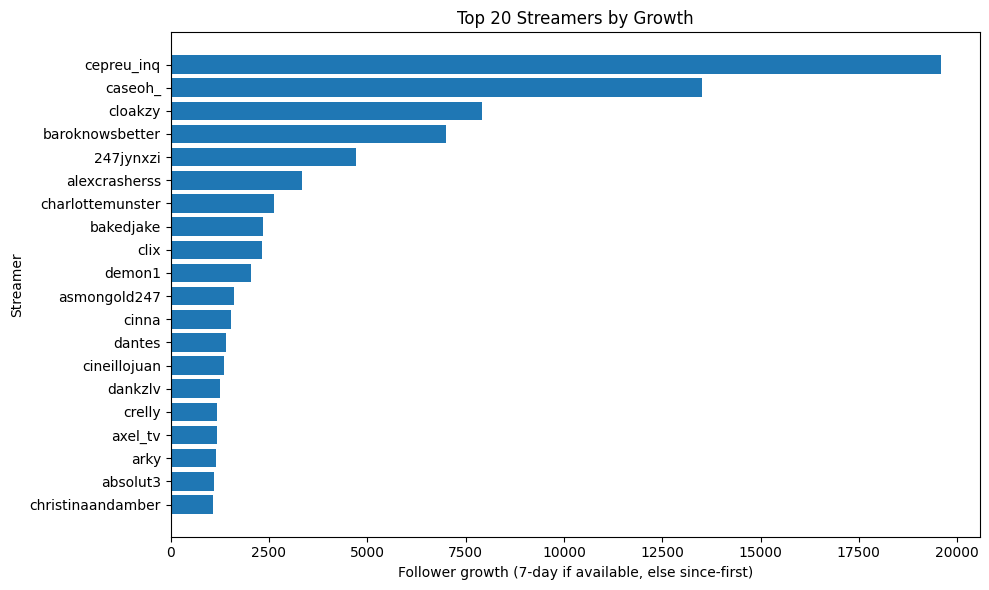

In [ ]:
top20 = latest.sort_values("success_abs", ascending=False).head(20)

plt.figure(figsize=(10, 6))
plt.barh(top20["username"], top20["success_abs"])
plt.gca().invert_yaxis()
plt.xlabel("Follower growth (7-day if available, else since-first)")
plt.ylabel("Streamer")
plt.title("Top 20 Streamers by Growth")
plt.tight_layout()
plt.show()
